# Assignment 4: Build Non-Linear Models Part 2

Juan Maldonado Franco  
DDS-8555 Predictive Analysis  
Mohamed Nabeel

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
for parent in [ROOT, *ROOT.parents]:
    if (parent / "DDS-8555 - Predictive Analysis").exists():
        COURSE = parent / "DDS-8555 - Predictive Analysis"
        break
else:
    COURSE = ROOT.parents[1]
DATA = COURSE / "data"
KAGGLE = DATA / "kaggle"
SUBMISSIONS = DATA / "submissions"
RANDOM_STATE = 42
pd.set_option("display.max_columns", 80)

## Conceptual Question 3

The fitted curve is f(X) = 1 + X - 2(X - 1)^2I(X >= 1).  For X < 1, the indicator is zero, so the curve is the line f(X) = 1 + X.  For X >= 1, the curve becomes 1 + X - 2(X - 1)^2, which is continuous at X = 1 but bends downward after the knot.  The slope is 1 before the knot and 1 - 4(X - 1) after the knot.  The curve therefore rises linearly until X = 1, then becomes concave downward and eventually declines.

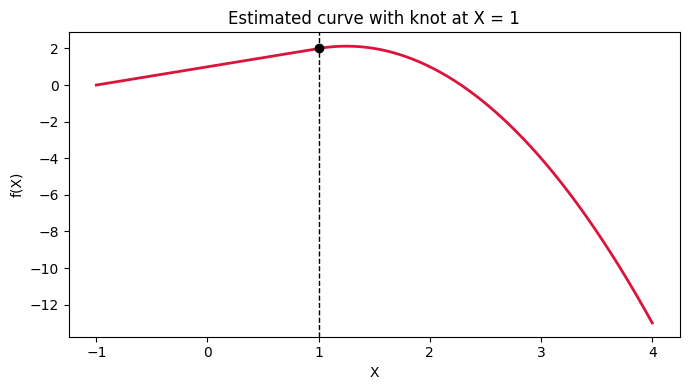

In [2]:
x = np.linspace(-1, 4, 400)
fx = 1 + x - 2 * ((x - 1) ** 2) * (x >= 1)
plt.figure(figsize=(7, 4))
plt.plot(x, fx, color="crimson", linewidth=2)
plt.axvline(1, color="black", linestyle="--", linewidth=1)
plt.scatter([1], [2], color="black", zorder=3)
plt.title("Estimated curve with knot at X = 1")
plt.xlabel("X")
plt.ylabel("f(X)")
plt.tight_layout()

The sketch makes the basis-function behavior visible.  The curve is continuous at the knot because both pieces equal 2 when X = 1, but the post-knot term changes the slope and creates the downward curvature requested in the question (James et al., 2023).

## Applied Question 8: Nonlinear Patterns in Auto

The Auto data set is used to test whether nonlinear functions of horsepower improve prediction of miles per gallon.  I treat this as an empirical question rather than an assumption: polynomial regression, step functions, and regression splines are compared with cross-validation and plotted so the selected shape is visible.

,missing_count
horsepower,0
mpg,0


,part,degree,cv_rmse
0,(a),1,4.909374
1,(a),2,4.363577
2,(a),3,4.365086
3,(a),4,4.383383
4,(a),5,4.336834
5,(a),6,4.330575
6,(a),7,4.320763
7,(a),8,4.349046
8,(a),9,4.386715
9,(a),10,4.433756


,part,degree,cv_rmse,delta_from_best
6,(a),7,4.320763,0.000000
5,(a),6,4.330575,0.009813
4,(a),5,4.336834,0.016072
7,(a),8,4.349046,0.028283
1,(a),2,4.363577,0.042815


Best polynomial degree by 5-fold CV: 7


,term,coefficient
0,intercept,23.445918
1,horsepower,1278.303227
2,horsepower^2,-8307.469287
3,horsepower^3,23801.509523
4,horsepower^4,-38293.766453
5,horsepower^5,35985.872749
6,horsepower^6,-18471.924855
7,horsepower^7,4002.865375


,part,bins,cv_rmse
0,(b),2,5.451271
1,(b),3,4.823162
2,(b),4,4.485108
3,(b),5,4.581382
4,(b),6,4.345419
5,(b),7,4.441480


Best step-function bin count by 5-fold CV: 6


,part,spline_df,cv_rmse
0,(c),3,4.365086
1,(c),4,4.351553
2,(c),5,4.304730
3,(c),6,4.349019
4,(c),7,4.385691
5,(c),8,4.382779


Best cubic spline df by 5-fold CV: 5


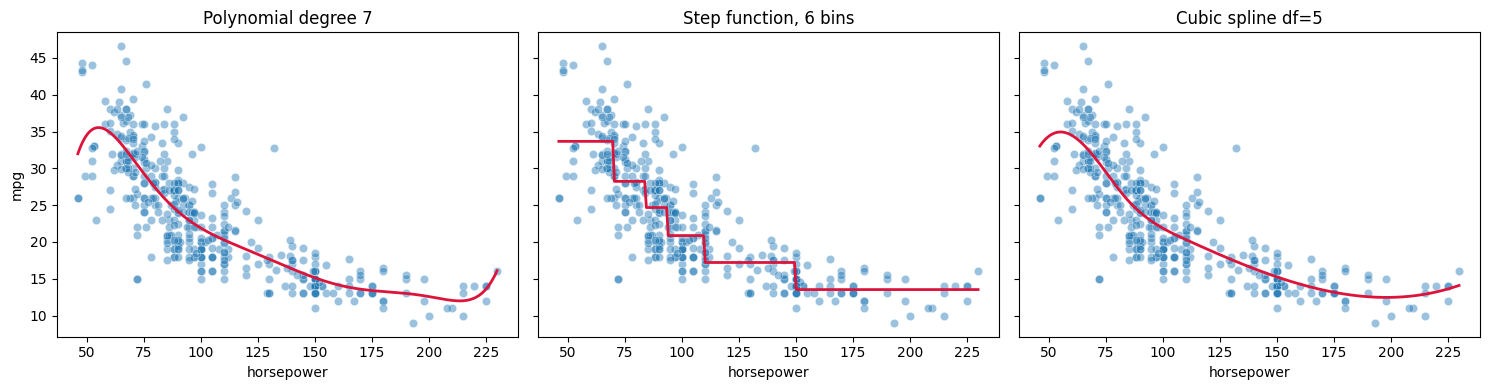

In [3]:
from ISLP import load_data
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from patsy import dmatrix

auto = load_data("Auto").dropna()
X_hp = auto[["horsepower"]]
y = auto["mpg"]
display(auto[["horsepower", "mpg"]].isna().sum().rename("missing_count").to_frame())
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# (a) Polynomial regression: compare degrees and report the fitted coefficients.
poly_rows = []
poly_models = {}
for degree in range(1, 11):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scale", StandardScaler()),
        ("lm", LinearRegression()),
    ])
    rmse = (-cross_val_score(model, X_hp, y, cv=kf, scoring="neg_root_mean_squared_error")).mean()
    model.fit(X_hp, y)
    poly_models[degree] = model
    poly_rows.append({"part": "(a)", "degree": degree, "cv_rmse": rmse})
poly_cv = pd.DataFrame(poly_rows)
display(poly_cv)
best_poly_degree = int(poly_cv.loc[poly_cv["cv_rmse"].idxmin(), "degree"])
poly_cv_ranked = poly_cv.assign(delta_from_best=lambda df: df["cv_rmse"] - df["cv_rmse"].min()).sort_values("cv_rmse")
display(poly_cv_ranked.head(5))
best_poly = poly_models[best_poly_degree]
poly_feature_names = best_poly.named_steps["poly"].get_feature_names_out(["horsepower"])
poly_coef = pd.DataFrame({
    "term": ["intercept"] + list(poly_feature_names),
    "coefficient": [best_poly.named_steps["lm"].intercept_] + list(best_poly.named_steps["lm"].coef_),
})
print(f"Best polynomial degree by 5-fold CV: {best_poly_degree}")
display(poly_coef)

# (b) Step functions: cut horsepower into bins and compare held-out RMSE.
step_rows = []
step_predictions = {}
hp_grid = pd.DataFrame({"horsepower": np.linspace(auto["horsepower"].min(), auto["horsepower"].max(), 250)})
for bins in range(2, 8):
    quantiles = np.unique(np.quantile(auto["horsepower"], np.linspace(0, 1, bins + 1)))
    rmses = []
    for train_idx, test_idx in kf.split(auto):
        train_df = auto.iloc[train_idx].copy()
        test_df = auto.iloc[test_idx].copy()
        train_design = pd.get_dummies(pd.cut(train_df["horsepower"], bins=quantiles, include_lowest=True), drop_first=True)
        test_design = pd.get_dummies(pd.cut(test_df["horsepower"], bins=quantiles, include_lowest=True), drop_first=True)
        test_design = test_design.reindex(columns=train_design.columns, fill_value=0)
        lm = LinearRegression().fit(train_design, train_df["mpg"])
        rmses.append(np.sqrt(mean_squared_error(test_df["mpg"], lm.predict(test_design))))
    step_rows.append({"part": "(b)", "bins": bins, "cv_rmse": np.mean(rmses)})
step_cv = pd.DataFrame(step_rows)
display(step_cv)
best_bins = int(step_cv.loc[step_cv["cv_rmse"].idxmin(), "bins"])
best_quantiles = np.unique(np.quantile(auto["horsepower"], np.linspace(0, 1, best_bins + 1)))
step_design = pd.get_dummies(pd.cut(auto["horsepower"], bins=best_quantiles, include_lowest=True), drop_first=True)
step_model = LinearRegression().fit(step_design, y)
grid_step_design = pd.get_dummies(pd.cut(hp_grid["horsepower"], bins=best_quantiles, include_lowest=True), drop_first=True)
grid_step_design = grid_step_design.reindex(columns=step_design.columns, fill_value=0)
step_predictions["best"] = step_model.predict(grid_step_design)
print(f"Best step-function bin count by 5-fold CV: {best_bins}")

# (c) Regression splines: compare degrees of freedom and report the smooth fit.
spline_rows = []
spline_models = {}
for df in range(3, 9):
    basis = dmatrix(f"bs(horsepower, df={df}, degree=3, include_intercept=False)", auto, return_type="dataframe")
    rmses = []
    for train_idx, test_idx in kf.split(basis):
        lm = LinearRegression().fit(basis.iloc[train_idx], y.iloc[train_idx])
        rmses.append(np.sqrt(mean_squared_error(y.iloc[test_idx], lm.predict(basis.iloc[test_idx]))))
    lm_full = LinearRegression().fit(basis, y)
    spline_models[df] = (lm_full, basis.design_info)
    spline_rows.append({"part": "(c)", "spline_df": df, "cv_rmse": np.mean(rmses)})
spline_cv = pd.DataFrame(spline_rows)
display(spline_cv)
best_spline_df = int(spline_cv.loc[spline_cv["cv_rmse"].idxmin(), "spline_df"])
best_spline_model, best_spline_design = spline_models[best_spline_df]
grid_basis = dmatrix(best_spline_design, hp_grid, return_type="dataframe")
print(f"Best cubic spline df by 5-fold CV: {best_spline_df}")

hp_grid["polynomial_fit"] = best_poly.predict(hp_grid)
hp_grid["step_fit"] = step_predictions["best"]
hp_grid["spline_fit"] = best_spline_model.predict(grid_basis)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, col, title in [
    (axes[0], "polynomial_fit", f"Polynomial degree {best_poly_degree}"),
    (axes[1], "step_fit", f"Step function, {best_bins} bins"),
    (axes[2], "spline_fit", f"Cubic spline df={best_spline_df}"),
]:
    sns.scatterplot(data=auto, x="horsepower", y="mpg", alpha=.45, ax=ax)
    ax.plot(hp_grid["horsepower"], hp_grid[col], color="crimson", linewidth=2)
    ax.set_title(title)
plt.tight_layout()

The polynomial table shows why the selected degree should not be read mechanically.  The cross-validation minimum identifies the degree with the smallest estimated error, but the best few degrees are close enough that a lower-degree curve can be more defensible if the goal is explanation rather than only prediction.  That parsimony point matters here because high-degree polynomial coefficients can become unstable near the boundaries of the horsepower range, while the spline fit gives local flexibility with less global wiggle (Hastie & Tibshirani, 1990; James et al., 2023).

## Kaggle Nonlinear Models

The Abalone competition work extends the nonlinear modeling theme from Auto using Chapter 7-style feature transformations.  A shared data preparation step holds missingness checks, physical-value cleaning, preprocessing, and the validation split constant.  The two fresh submissions are polynomial ridge regression and spline ridge regression, so the leaderboard evidence is tied directly to nonlinear basis expansions rather than to tree ensembles.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, SplineTransformer, StandardScaler

abalone_raw = pd.read_csv(KAGGLE / "playground-series-s4e4" / "train.csv")
abalone_test_raw = pd.read_csv(KAGGLE / "playground-series-s4e4" / "test.csv")
expected_columns = {"id", "Sex", "Length", "Diameter", "Height", "Whole weight", "Whole weight.1", "Whole weight.2", "Shell weight", "Rings"}
expected_test_columns = expected_columns - {"Rings"}
missing_expected = sorted(expected_columns - set(abalone_raw.columns))
missing_expected_test = sorted(expected_test_columns - set(abalone_test_raw.columns))
duplicate_ids = int(abalone_raw["id"].duplicated().sum()) if "id" in abalone_raw else 0
duplicate_test_ids = int(abalone_test_raw["id"].duplicated().sum()) if "id" in abalone_test_raw else 0
missing_by_column = abalone_raw.isna().sum()
missing_by_column_test = abalone_test_raw.isna().sum()
numeric_cols_raw = abalone_raw.select_dtypes(include=np.number).columns.tolist()
physical_cols = [c for c in numeric_cols_raw if c not in ["id", "Rings"]]
nonpositive_physical = {c: int((abalone_raw[c] <= 0).sum()) for c in physical_cols}
nonpositive_physical_test = {c: int((abalone_test_raw[c] <= 0).sum()) for c in physical_cols if c in abalone_test_raw.columns}
display(pd.DataFrame({
    "quality_check": [
        "train_rows",
        "test_rows",
        "missing_expected_train_columns",
        "missing_expected_test_columns",
        "duplicate_train_ids",
        "duplicate_test_ids",
        "train_total_missing_values",
        "test_total_missing_values",
        "train_nonpositive_physical_values",
        "test_nonpositive_physical_values",
    ],
    "value": [
        len(abalone_raw),
        len(abalone_test_raw),
        missing_expected,
        missing_expected_test,
        duplicate_ids,
        duplicate_test_ids,
        int(missing_by_column.sum()),
        int(missing_by_column_test.sum()),
        nonpositive_physical,
        nonpositive_physical_test,
    ],
}))

if missing_expected:
    raise ValueError(f"Missing expected Abalone columns: {missing_expected}")
if missing_expected_test:
    raise ValueError(f"Missing expected Abalone test columns: {missing_expected_test}")

def clean_abalone_frame(frame, *, has_target):
    cleaned = frame.copy()
    if has_target and cleaned["id"].duplicated().any():
        cleaned = cleaned.drop_duplicates(subset=["id"], keep="first")
    if has_target and cleaned["Rings"].isna().any():
        cleaned = cleaned.dropna(subset=["Rings"])
    for col in physical_cols:
        if col in cleaned.columns:
            cleaned.loc[cleaned[col] <= 0, col] = np.nan
    return cleaned

abalone = clean_abalone_frame(abalone_raw, has_target=True)
abalone_test = clean_abalone_frame(abalone_test_raw, has_target=False)
if duplicate_ids:
    print(f"Dropped {duplicate_ids} duplicate training ids before modeling.")
display(abalone.isna().sum().rename("train_missing_after_cleaning_flags").to_frame().query("train_missing_after_cleaning_flags > 0"))
display(abalone_test.isna().sum().rename("test_missing_after_cleaning_flags").to_frame().query("test_missing_after_cleaning_flags > 0"))

X = abalone.drop(columns=["Rings"])
y = abalone["Rings"]
numeric_predictors = [c for c in X.columns if c not in ["id", "Sex"]]
X_train, X_valid, y_train, y_valid = train_test_split(X.drop(columns=["id"]), y, test_size=.2, random_state=RANDOM_STATE)
X_full = X.drop(columns=["id"])
X_test = abalone_test.drop(columns=["id"])
baseline_pred = np.repeat(y_train.mean(), len(y_valid))
baseline_rmsle = np.sqrt(mean_squared_log_error(y_valid, baseline_pred))
display(pd.DataFrame({
    "setup_check": ["training_rows", "validation_rows", "mean_baseline_rmsle", "target_min", "target_max"],
    "value": [len(X_train), len(X_valid), baseline_rmsle, y.min(), y.max()],
}))

def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_log_error(y_true, np.maximum(y_pred, 1)))

def coefficient_table(model, top_n=12):
    coef = model.named_steps["model"].coef_
    try:
        names = model.named_steps["pre"].get_feature_names_out()
    except Exception:
        names = [f"x{i}" for i in range(len(coef))]
    return (
        pd.DataFrame({"feature": names, "coefficient": coef, "abs_coefficient": np.abs(coef)})
        .sort_values("abs_coefficient", ascending=False)
        .head(top_n)
        .drop(columns="abs_coefficient")
    )

def residual_summary(name, y_true, y_pred):
    residuals = y_true - np.maximum(y_pred, 1)
    return {
        "model": name,
        "validation_rmsle": rmsle(y_true, y_pred),
        "mean_residual": residuals.mean(),
        "median_abs_residual": np.median(np.abs(residuals)),
        "residual_skew": pd.Series(residuals).skew(),
        "corr_abs_residual_pred": np.corrcoef(np.abs(residuals), np.maximum(y_pred, 1))[0, 1],
    }

def error_by_prediction_range(name, y_true, y_pred):
    frame = pd.DataFrame({"actual": y_true.to_numpy(), "predicted": np.maximum(y_pred, 1)})
    frame["abs_residual"] = np.abs(frame["actual"] - frame["predicted"])
    frame["prediction_band"] = pd.qcut(frame["predicted"], q=4, duplicates="drop")
    return (
        frame.groupby("prediction_band", observed=True)
        .agg(model=("predicted", lambda s: name), n=("actual", "size"), mean_prediction=("predicted", "mean"), mean_abs_residual=("abs_residual", "mean"))
        .reset_index()
    )

,quality_check,value
0,train_rows,90615
1,test_rows,60411
2,missing_expected_train_columns,[]
3,missing_expected_test_columns,[]
4,duplicate_train_ids,0
5,duplicate_test_ids,0
6,train_total_missing_values,0
7,test_total_missing_values,0
8,train_nonpositive_physical_values,"{'Length': 0, 'Diameter': 0, 'Height': 6, 'Who..."
9,test_nonpositive_physical_values,"{'Length': 0, 'Diameter': 0, 'Height': 2, 'Who..."


,train_missing_after_cleaning_flags
Height,6


,test_missing_after_cleaning_flags
Height,2


,setup_check,value
0,training_rows,72492.000000
1,validation_rows,18123.000000
2,mean_baseline_rmsle,0.290949
3,target_min,1.000000
4,target_max,29.000000


### Kaggle Model 1: Polynomial Ridge

The first fresh Kaggle model uses second-degree polynomial basis functions for the numeric Abalone measurements, then applies ridge regression to stabilize the expanded design matrix.  This keeps the model aligned with the Week 4 nonlinearity methods while still recognizing that length, diameter, height, and weight variables are highly related.

In [5]:
cat_pipe = Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
poly_num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scale", StandardScaler()),
])
poly_pre = ColumnTransformer([
    ("cat", cat_pipe, ["Sex"]),
    ("poly_num", poly_num_pipe, numeric_predictors),
])
poly_ridge_model = Pipeline([
    ("pre", poly_pre),
    ("model", Ridge(alpha=25.0)),
])
poly_ridge_model.fit(X_train, y_train)
poly_valid_pred = poly_ridge_model.predict(X_valid)
poly_ridge_rmsle = rmsle(y_valid, poly_valid_pred)
poly_ridge_full = Pipeline([
    ("pre", poly_pre),
    ("model", Ridge(alpha=25.0)),
])
poly_ridge_full.fit(X_full, y)
poly_test_pred = np.maximum(poly_ridge_full.predict(X_test), 1)
poly_submission_file = "A4_polynomial_ridge_chapter7_playground_series_s4e4.csv"
pd.DataFrame({"id": abalone_test["id"], "Rings": poly_test_pred}).to_csv(SUBMISSIONS / poly_submission_file, index=False)
display(pd.DataFrame({
    "model": ["Polynomial ridge"],
    "validation_rmsle": [poly_ridge_rmsle],
    "submission_file": [poly_submission_file],
    "submission_rows": [len(poly_test_pred)],
}))
display(coefficient_table(poly_ridge_model))

,model,validation_rmsle,submission_file,submission_rows
0,Polynomial ridge,0.159189,A4_polynomial_ridge_chapter7_playground_series...,60411


,feature,coefficient
32,poly_num__Whole weight.1^2,4.173108
6,poly_num__Whole weight,2.741976
25,poly_num__Height Whole weight.1,-2.486659
7,poly_num__Whole weight.1,-2.294102
9,poly_num__Shell weight,2.255568
22,poly_num__Diameter Shell weight,2.007809
27,poly_num__Height Shell weight,1.939422
36,poly_num__Whole weight.2 Shell weight,-1.902530
34,poly_num__Whole weight.1 Shell weight,-1.619845
19,poly_num__Diameter Whole weight,1.615224


The polynomial ridge model improves over the mean baseline and gives interpretable coefficient evidence after scaling.  The largest terms should not be read as causal effects because the Abalone measurements move together, but their signs and relative magnitudes show which transformed measurements carry the prediction signal.  Ridge is a practical safeguard here because polynomial expansions increase collinearity instead of removing it (James et al., 2023).

### Kaggle Model 2: Spline Ridge

The second fresh Kaggle model uses cubic spline basis functions for the same numeric measurements.  A spline basis is more local than a global polynomial, so it can bend differently across the measurement range without requiring a high-degree polynomial over the entire domain.

In [6]:
spline_num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("spline", SplineTransformer(n_knots=5, degree=3, include_bias=False)),
    ("scale", StandardScaler()),
])
spline_pre = ColumnTransformer([
    ("cat", cat_pipe, ["Sex"]),
    ("spline_num", spline_num_pipe, numeric_predictors),
])
spline_ridge_model = Pipeline([
    ("pre", spline_pre),
    ("model", Ridge(alpha=10.0)),
])
spline_ridge_model.fit(X_train, y_train)
spline_valid_pred = spline_ridge_model.predict(X_valid)
spline_ridge_rmsle = rmsle(y_valid, spline_valid_pred)
spline_ridge_full = Pipeline([
    ("pre", spline_pre),
    ("model", Ridge(alpha=10.0)),
])
spline_ridge_full.fit(X_full, y)
spline_test_pred = np.maximum(spline_ridge_full.predict(X_test), 1)
spline_submission_file = "A4_spline_ridge_chapter7_playground_series_s4e4.csv"
pd.DataFrame({"id": abalone_test["id"], "Rings": spline_test_pred}).to_csv(SUBMISSIONS / spline_submission_file, index=False)
display(pd.DataFrame({
    "model": ["Spline ridge"],
    "validation_rmsle": [spline_ridge_rmsle],
    "submission_file": [spline_submission_file],
    "submission_rows": [len(spline_test_pred)],
}))
display(coefficient_table(spline_ridge_model))

,model,validation_rmsle,submission_file,submission_rows
0,Spline ridge,0.16015,A4_spline_ridge_chapter7_playground_series_s4e...,60411


,feature,coefficient
22,spline_num__Whole weight_sp_1,-2.502383
28,spline_num__Whole weight.1_sp_1,1.948806
30,spline_num__Whole weight.1_sp_3,-1.664199
42,spline_num__Shell weight_sp_3,1.307452
40,spline_num__Shell weight_sp_1,-1.173294
24,spline_num__Whole weight_sp_3,0.946259
8,spline_num__Length_sp_5,-0.742319
12,spline_num__Diameter_sp_3,0.688677
43,spline_num__Shell weight_sp_4,0.663530
31,spline_num__Whole weight.1_sp_4,-0.547869


The spline ridge model answers the same Kaggle task with a different nonlinear assumption.  Instead of forcing every measurement into one global quadratic surface, it lets each numeric predictor have local bends across its range.  That structure is a better match for a biological growth problem when the relationship between body measurements and rings may flatten or change rate across sizes (Hastie & Tibshirani, 1990; Nash et al., 1994).

,model,validation_rmsle,submission_file
1,Polynomial ridge,0.159189,A4_polynomial_ridge_chapter7_playground_series...
2,Spline ridge,0.160150,A4_spline_ridge_chapter7_playground_series_s4e...
0,Mean baseline,0.290949,


,model,validation_rmsle,mean_residual,median_abs_residual,residual_skew,corr_abs_residual_pred
0,Polynomial ridge,0.159189,0.001029,0.946750,1.492743,0.411876
1,Spline ridge,0.160150,0.003266,0.953966,1.491097,0.406563


,prediction_band,model,n,mean_prediction,mean_abs_residual
0,"(1.806, 7.895]",Polynomial ridge,4531,6.568432,0.789679
1,"(7.895, 9.692]",Polynomial ridge,4531,8.862919,0.952976
2,"(9.692, 11.211]",Polynomial ridge,4530,10.433774,1.337425
3,"(11.211, 24.017]",Polynomial ridge,4531,12.913021,2.297422
4,"(0.999, 7.854]",Spline ridge,4531,6.571495,0.803161
5,"(7.854, 9.633]",Spline ridge,4531,8.800436,0.954116
6,"(9.633, 11.28]",Spline ridge,4530,10.420057,1.356600
7,"(11.28, 21.506]",Spline ridge,4531,12.977209,2.286997


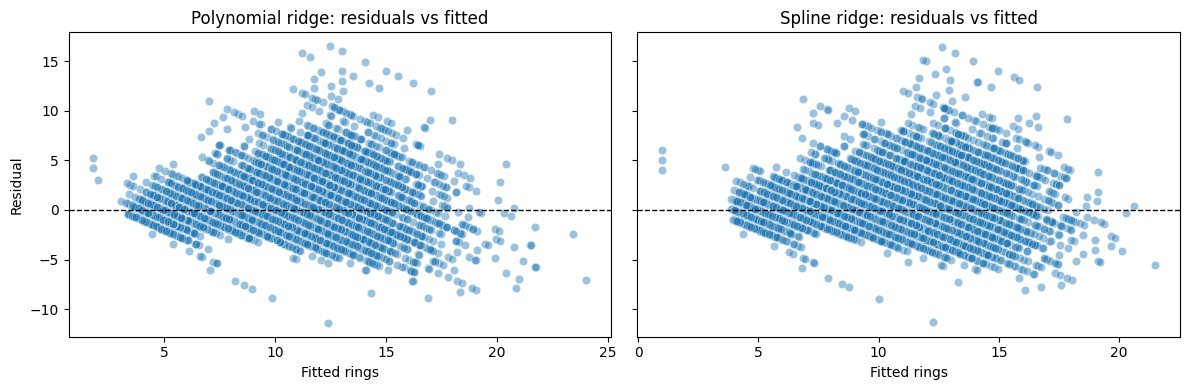

In [7]:
kaggle_a4_comparison = pd.DataFrame([
    {"model": "Mean baseline", "validation_rmsle": baseline_rmsle, "submission_file": ""},
    {"model": "Polynomial ridge", "validation_rmsle": poly_ridge_rmsle, "submission_file": poly_submission_file},
    {"model": "Spline ridge", "validation_rmsle": spline_ridge_rmsle, "submission_file": spline_submission_file},
]).sort_values("validation_rmsle")
display(kaggle_a4_comparison)

residual_diagnostics = pd.DataFrame([
    residual_summary("Polynomial ridge", y_valid, poly_valid_pred),
    residual_summary("Spline ridge", y_valid, spline_valid_pred),
])
display(residual_diagnostics)
display(pd.concat([
    error_by_prediction_range("Polynomial ridge", y_valid, poly_valid_pred),
    error_by_prediction_range("Spline ridge", y_valid, spline_valid_pred),
], ignore_index=True))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, name, pred in [
    (axes[0], "Polynomial ridge", np.maximum(poly_valid_pred, 1)),
    (axes[1], "Spline ridge", np.maximum(spline_valid_pred, 1)),
]:
    residuals = y_valid - pred
    sns.scatterplot(x=pred, y=residuals, alpha=.45, ax=ax)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{name}: residuals vs fitted")
    ax.set_xlabel("Fitted rings")
    ax.set_ylabel("Residual")
plt.tight_layout()

The comparison table keeps the two Kaggle submissions connected to the same validation split.  The residual summaries add an assumption check that is appropriate for prediction models: errors should not systematically widen or shift across the fitted range.  The error-by-prediction-range table makes that issue visible rather than relying only on a single RMSLE value.  The evidence cell below documents the fresh submitted files and their leaderboard status.

In [8]:
import re

status_path = SUBMISSIONS / "kaggle_submission_status_playground-series-s4e4.txt"
for encoding in ("utf-16", "utf-8"):
    try:
        text = status_path.read_text(encoding=encoding)
        break
    except UnicodeError:
        continue

records = []
expected_files = set(['A4_polynomial_ridge_chapter7_playground_series_s4e4.csv', 'A4_spline_ridge_chapter7_playground_series_s4e4.csv'])
for line in text.splitlines():
    parts = re.split(r"\s{2,}", line.strip())
    if len(parts) >= 7 and parts[0].isdigit() and "A4_" in parts[1] and parts[1] in expected_files:
        records.append({
            "ref": parts[0],
            "fileName": parts[1],
            "date": parts[2],
            "description": parts[3],
            "status": parts[4],
            "publicScore": parts[5],
            "privateScore": parts[6],
        })

display(pd.DataFrame(records))
display(pd.DataFrame({
    "submission_file": ['A4_polynomial_ridge_chapter7_playground_series_s4e4.csv', 'A4_spline_ridge_chapter7_playground_series_s4e4.csv'],
    "exists_locally": [(SUBMISSIONS / file).exists() for file in ['A4_polynomial_ridge_chapter7_playground_series_s4e4.csv', 'A4_spline_ridge_chapter7_playground_series_s4e4.csv']],
}))
display(pd.DataFrame({
    "evidence": ["Public GitHub repository", "Notebook path in repository"],
    "value": [
        "https://github.com/maldo81/dds-8555-predictive-analysis",
        "Week 4/Assignment 4/MaldonadoJDDS8555-4.ipynb",
    ],
}))

,ref,fileName,date,description,status,publicScore,privateScore
0,53576849,A4_spline_ridge_chapter7_playground_series_s4e...,2026-06-11 17:25:56.927000,A4 spline ridge chapter 7 nonlinear basis,SubmissionStatus.COMPLETE,0.15749,0.15716
1,53576846,A4_polynomial_ridge_chapter7_playground_series...,2026-06-11 17:25:48.110000,A4 polynomial ridge chapter 7 nonlinear basis,SubmissionStatus.COMPLETE,0.15683,0.15611


,submission_file,exists_locally
0,A4_polynomial_ridge_chapter7_playground_series...,True
1,A4_spline_ridge_chapter7_playground_series_s4e...,True


,evidence,value
0,Public GitHub repository,https://github.com/maldo81/dds-8555-predictive...
1,Notebook path in repository,Week 4/Assignment 4/MaldonadoJDDS8555-4.ipynb


## Interpretation

For Auto, the fitted plots and cross-validation tables show the same substantive pattern: mpg falls quickly as horsepower increases and then flattens among high-horsepower cars.  A straight line misses that curvature.  Polynomial regression is smooth but can wiggle at the boundaries, step functions are easy to read but impose abrupt jumps, and splines give a smoother local fit.  Missingness and physically impossible Abalone measurements were checked before modeling because nonlinear transformations can silently amplify data-quality problems if rows are dropped without explanation (Little & Rubin, 2019; Tukey, 1977).  For Abalone, the polynomial ridge and spline ridge submissions make the nonlinear basis choice explicit.  The assumption investigation focuses on validation behavior, residual structure, error by fitted range, missing-data handling, and overfitting control because these prediction models are being judged by held-out RMSLE rather than by ordinary least squares inference alone.  The biological interpretation remains limited: the models predict ring count from measurements, but they do not explain abalone age causally (Nash et al., 1994).

## References

Hastie, T., & Tibshirani, R. (1990). *Generalized additive models*.  Chapman and Hall.

James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An introduction to statistical learning: With applications in Python*.  Springer. https://doi.org/10.1007/978-3-031-38747-0

Little, R.  J.  A., & Rubin, D.  B. (2019). *Statistical analysis with missing data* (3rd ed.).  Wiley. https://doi.org/10.1002/9781119482260

Nash, W.  J., Sellers, T.  L., Talbot, S.  R., Cawthorn, A.  J., & Ford, W.  B. (1994). *The population biology of abalone (Haliotis species) in Tasmania.  I.  Blacklip abalone (H. rubra) from the north coast and islands of Bass Strait* (Technical Report No.  48).  Sea Fisheries Division.

Tukey, J.  W. (1977). *Exploratory data analysis*.  Addison-Wesley.